# **CÁTEDRA FINAL**

## Implementación y análisis de un Multilayer Perceptron en PyTorch

| **Ítem** | **Detalle** |
|---|---|
| **Asignatura** | Deep Learning |
| **Ponderación** | 60 % de la nota final |
| **Modalidad** | Grupos del proyecto |
| **Fecha de entrega** | Martes 29 de agosto de 2026 |

> **Alumnos** : Guido Ríos Ciaffaroni
>> **Correo** : *guidoriosciaffaroni@gmail.com*


> **Alumnos** : Eduardo Opazo  
>> **Correo** : *edo.opazo.d@gmail.com*

# F1

##**Contexto del problema y variable objetivo**

###**1. Contexto del problema**

La transición hacia sistemas de transporte sostenibles ha impulsado el uso de vehículos eléctricos. Uno de sus componentes más importantes es la batería, debido a que su estado influye directamente en la autonomía, el rendimiento, la confiabilidad y los costos de mantenimiento del vehículo.

Las baterías experimentan una degradación progresiva como consecuencia de diferentes condiciones de uso y operación. Entre los factores que pueden influir en este proceso se encuentran:

* La distancia total recorrida.
* La velocidad promedio de los viajes.
* La temperatura ambiental.
* La duración de los viajes.
* La cantidad de ciclos de carga.
* La proporción de cargas rápidas.
* La temperatura promedio de funcionamiento de la batería.

Detectar anticipadamente una disminución en la salud de la batería permite mejorar la planificación del mantenimiento, reducir fallas inesperadas y apoyar decisiones relacionadas con su reparación o reemplazo.

En este proyecto se utiliza el conjunto de datos sintético **Synthetic EV Battery Health Data**, compuesto por **10.000 observaciones** y **8 variables numéricas**. Cada observación representa las condiciones acumuladas de uso de una batería y su porcentaje estimado de salud.

El propósito del análisis es construir un modelo de aprendizaje supervisado capaz de estimar la salud de una batería a partir de sus condiciones de utilización y funcionamiento. Como el valor que se desea predecir es numérico y continuo, el problema corresponde a una tarea de **regresión**.

---

## Librerias

In [77]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Reproducibilidad

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

##**Descargar o cargar el conjunto de datos mediante código reproducible.**

## Descarga del dataset PlantVillage desde Kaggle mediante `curl`

En esta etapa se descargará directamente el archivo comprimido del dataset
**PlantVillage** utilizando `curl` y el endpoint de descarga proporcionado
por Kaggle.

El dataset será almacenado en:

`/content/plantvillage.zip`

Esta estrategia permite mantener inicialmente el conjunto de datos comprimido,
verificar su descarga e integridad y posteriormente descomprimirlo solamente
cuando sea necesario para el análisis de imágenes.

In [5]:
%%bash

# ============================================================
# DESCARGA DEL DATASET PLANTVILLAGE DESDE KAGGLE
# ============================================================

curl -L \
  -o /content/plantvillage.zip \
  "https://www.kaggle.com/api/v1/datasets/download/mohitsingh1804/plantvillage"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  817M  100  817M    0     0  99.0M      0  0:00:08  0:00:08 --:--:--  128M


In [6]:
# ============================================================
# VERIFICACIÓN DE LA DESCARGA
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    print("✅ Dataset descargado correctamente.")
    print(f"Ruta: {ruta_zip}")

else:

    print("❌ No se encontró el archivo descargado.")

✅ Dataset descargado correctamente.
Ruta: /content/plantvillage.zip


In [7]:
# ============================================================
# TAMAÑO DEL ARCHIVO DESCARGADO
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    tamaño_bytes = os.path.getsize(ruta_zip)

    tamaño_mb = tamaño_bytes / (1024 ** 2)

    tamaño_gb = tamaño_bytes / (1024 ** 3)

    print("=" * 60)
    print("INFORMACIÓN DEL ARCHIVO")
    print("=" * 60)

    print(f"Archivo : {ruta_zip}")
    print(f"Tamaño  : {tamaño_mb:.2f} MB")
    print(f"Tamaño  : {tamaño_gb:.3f} GB")

else:

    print("❌ El archivo no existe.")

INFORMACIÓN DEL ARCHIVO
Archivo : /content/plantvillage.zip
Tamaño  : 817.63 MB
Tamaño  : 0.798 GB


In [8]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL ARCHIVO ZIP
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

try:

    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

        archivo_problematico = archivo_zip.testzip()

    if archivo_problematico is None:

        print("✅ El archivo ZIP es válido y no presenta errores detectables.")

    else:

        print("⚠️ Se detectó un archivo problemático dentro del ZIP:")
        print(archivo_problematico)

except zipfile.BadZipFile:

    print("❌ El archivo descargado no corresponde a un ZIP válido.")

✅ El archivo ZIP es válido y no presenta errores detectables.


In [9]:
# ============================================================
# INSPECCIÓN DEL CONTENIDO DEL ZIP
# SIN DESCOMPRIMIR
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

    archivos = archivo_zip.namelist()


print("=" * 70)
print("CONTENIDO DEL DATASET")
print("=" * 70)

print(f"Número total de elementos: {len(archivos):,}")

print("\nPrimeros 30 elementos:\n")

for archivo in archivos[:30]:

    print(archivo)

CONTENIDO DEL DATASET
Número total de elementos: 54,305

Primeros 30 elementos:

PlantVillage/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
PlantVillage/train/Apple___Apple_scab/01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
PlantVillage/train/Apple___Apple_scab/0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
PlantVillage/train/Apple___Apple_scab/023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
PlantVillage/train/Apple___Apple_scab/0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
PlantVillage/train/Apple___Apple_scab/029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG
PlantVillage/train/Apple___Apple_scab/0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG
PlantVillage/train/Apple___Apple_scab/03eccb1a-0368-4ac7-9f48-7546037b775a___FREC_Scab 3334.JPG
PlantVillage/train/Apple___Apple_scab/0537ad56-3d24-4e97-a947-65b9b37f8988___FREC_Scab 3079.JPG
PlantVillage/train/Apple___Apple_scab/058d5e64-2c57-45b

In [10]:
# ============================================================
# CREACIÓN DEL DIRECTORIO DE EXTRACCIÓN
# ============================================================

import os

DIRECTORIO_DATOS = "/content/plantvillage"

os.makedirs(
    DIRECTORIO_DATOS,
    exist_ok=True
)

print("✅ Directorio creado:")
print(DIRECTORIO_DATOS)

✅ Directorio creado:
/content/plantvillage


In [11]:
%%bash

unzip -q /content/plantvillage.zip \
       -d /content/plantvillage

## Filtrado de clases del dataset PlantVillage

En esta etapa se eliminarán del conjunto de datos determinadas clases de plantas
que no serán utilizadas en el experimento.

La eliminación se realizará tanto sobre el conjunto `train` como sobre el conjunto
`val`.

Se eliminarán todas las carpetas cuyo nombre comience con:

- Apple
- Cherry
- Corn
- Grape
- Orange
- Peach
- Pepper
- Raspberry
- Soybean
- Squash
- Strawberry

Antes de realizar la eliminación definitiva se verificará qué directorios cumplen
estas condiciones, con el objetivo de evitar la eliminación accidental de clases
que deben conservarse.

In [78]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN DE RUTAS Y CLASES A ELIMINAR
# ============================================================

import os
import shutil


# ------------------------------------------------------------
# Directorio principal del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"


# Directorios de entrenamiento y validación
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# Prefijos de las clases que se desean eliminar
# ------------------------------------------------------------

PREFIJOS_ELIMINAR = (
    "Apple",
    "Blueberry",
    "Cherry",
    "Corn",
    "Grape",
    "Orange",
    "Peach",
    "Potato",
    "Pepper",
    "Raspberry",
    "Soybean",
    "Squash",
    "Strawberry"
)


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")

print("\nPrefijos que serán eliminados:")

for prefijo in PREFIJOS_ELIMINAR:
    print(f" - {prefijo}")

CONFIGURACIÓN
Train : /content/plantvillage/PlantVillage/train
Val   : /content/plantvillage/PlantVillage/val

Prefijos que serán eliminados:
 - Apple
 - Blueberry
 - Cherry
 - Corn
 - Grape
 - Orange
 - Peach
 - Potato
 - Pepper
 - Raspberry
 - Soybean
 - Squash
 - Strawberry


In [79]:
# ============================================================
# BLOQUE 3
# MOSTRAR TODAS LAS CLASES DISPONIBLES
# ============================================================

def mostrar_clases(directorio, nombre_conjunto):
    """
    Muestra las carpetas correspondientes a las clases de un conjunto.
    """

    print("\n" + "=" * 70)
    print(f"CLASES DISPONIBLES EN {nombre_conjunto.upper()}")
    print("=" * 70)

    if not os.path.exists(directorio):
        print(f"❌ No existe el directorio: {directorio}")
        return []

    clases = sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(os.path.join(directorio, carpeta))
    )

    for i, clase in enumerate(clases, start=1):
        print(f"{i:02d}. {clase}")

    print(f"\nNúmero total de clases: {len(clases)}")

    return clases


clases_train = mostrar_clases(
    TRAIN_DIR,
    "train"
)

clases_val = mostrar_clases(
    VAL_DIR,
    "val"
)


CLASES DISPONIBLES EN TRAIN
❌ No existe el directorio: /content/plantvillage/PlantVillage/train

CLASES DISPONIBLES EN VAL
❌ No existe el directorio: /content/plantvillage/PlantVillage/val


In [80]:
# ============================================================
# BLOQUE 4
# IDENTIFICAR CARPETAS QUE SERÁN ELIMINADAS
# ============================================================

def identificar_carpetas_eliminar(directorio):
    """
    Identifica las carpetas cuyo nombre comienza
    con alguno de los prefijos definidos.
    """

    carpetas_eliminar = []

    if not os.path.exists(directorio):
        return carpetas_eliminar

    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )

        # Comprobar que sea realmente una carpeta
        if os.path.isdir(ruta_carpeta):

            # Verificar si el nombre comienza con alguno
            # de los prefijos indicados
            if carpeta.startswith(PREFIJOS_ELIMINAR):

                carpetas_eliminar.append(carpeta)

    return sorted(carpetas_eliminar)


eliminar_train = identificar_carpetas_eliminar(
    TRAIN_DIR
)

eliminar_val = identificar_carpetas_eliminar(
    VAL_DIR
)


print("=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN")
print("=" * 70)

for carpeta in eliminar_train:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_train)} carpetas")


print("\n" + "=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE VAL")
print("=" * 70)

for carpeta in eliminar_val:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_val)} carpetas")

CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN

Total: 0 carpetas

CARPETAS QUE SERÍAN ELIMINADAS DE VAL

Total: 0 carpetas


In [81]:
# ============================================================
# BLOQUE 5
# CONTAR IMÁGENES QUE SERÁN ELIMINADAS
# ============================================================

def contar_archivos_carpeta(ruta):
    """
    Cuenta todos los archivos contenidos en una carpeta
    y sus subdirectorios.
    """

    contador = 0

    for _, _, archivos in os.walk(ruta):
        contador += len(archivos)

    return contador


def resumen_eliminacion(directorio, carpetas):

    total_imagenes = 0

    for carpeta in carpetas:

        ruta = os.path.join(
            directorio,
            carpeta
        )

        cantidad = contar_archivos_carpeta(ruta)

        total_imagenes += cantidad

        print(
            f"{carpeta:<65} "
            f"{cantidad:>6} imágenes"
        )

    return total_imagenes


print("=" * 85)
print("IMÁGENES A ELIMINAR DE TRAIN")
print("=" * 85)

imagenes_train_eliminar = resumen_eliminacion(
    TRAIN_DIR,
    eliminar_train
)

print(
    f"\nTotal imágenes a eliminar de train: "
    f"{imagenes_train_eliminar:,}"
)


print("\n" + "=" * 85)
print("IMÁGENES A ELIMINAR DE VAL")
print("=" * 85)

imagenes_val_eliminar = resumen_eliminacion(
    VAL_DIR,
    eliminar_val
)

print(
    f"\nTotal imágenes a eliminar de val: "
    f"{imagenes_val_eliminar:,}"
)

IMÁGENES A ELIMINAR DE TRAIN

Total imágenes a eliminar de train: 0

IMÁGENES A ELIMINAR DE VAL

Total imágenes a eliminar de val: 0


In [82]:
# ============================================================
# BLOQUE 6
# ELIMINACIÓN DEFINITIVA DE LAS CARPETAS
# ============================================================

def eliminar_carpetas(directorio, prefijos):
    """
    Elimina todas las carpetas cuyo nombre comienza con
    cualquiera de los prefijos especificados.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio que contiene las clases.

    prefijos : tuple
        Prefijos correspondientes a las clases
        que deben eliminarse.
    """

    eliminadas = []

    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")

        return eliminadas


    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )


        if (
            os.path.isdir(ruta_carpeta)
            and carpeta.startswith(prefijos)
        ):

            # Eliminar carpeta y todo su contenido
            shutil.rmtree(ruta_carpeta)

            eliminadas.append(carpeta)

            print(f"🗑️ Eliminada: {carpeta}")


    return sorted(eliminadas)

In [83]:
# ============================================================
# EJECUTAR ELIMINACIÓN
# ============================================================

print("=" * 70)
print("ELIMINANDO CLASES DE TRAIN")
print("=" * 70)

eliminadas_train = eliminar_carpetas(
    TRAIN_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("ELIMINANDO CLASES DE VAL")
print("=" * 70)

eliminadas_val = eliminar_carpetas(
    VAL_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)

print(
    f"Carpetas eliminadas de train: "
    f"{len(eliminadas_train)}"
)

print(
    f"Carpetas eliminadas de val  : "
    f"{len(eliminadas_val)}"
)

ELIMINANDO CLASES DE TRAIN
❌ No existe el directorio: /content/plantvillage/PlantVillage/train

ELIMINANDO CLASES DE VAL
❌ No existe el directorio: /content/plantvillage/PlantVillage/val

PROCESO FINALIZADO
Carpetas eliminadas de train: 0
Carpetas eliminadas de val  : 0


In [18]:
# ============================================================
# BLOQUE 7
# VERIFICACIÓN POSTERIOR A LA ELIMINACIÓN
# ============================================================

def obtener_clases(directorio):

    return sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(
            os.path.join(
                directorio,
                carpeta
            )
        )
    )


clases_train_final = obtener_clases(
    TRAIN_DIR
)

clases_val_final = obtener_clases(
    VAL_DIR
)


print("=" * 70)
print("CLASES RESTANTES EN TRAIN")
print("=" * 70)

for i, clase in enumerate(
    clases_train_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_train_final)}"
)


print("\n" + "=" * 70)
print("CLASES RESTANTES EN VAL")
print("=" * 70)

for i, clase in enumerate(
    clases_val_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_val_final)}"
)

CLASES RESTANTES EN TRAIN
01. Potato___Early_blight
02. Potato___Late_blight
03. Potato___healthy
04. Tomato___Bacterial_spot
05. Tomato___Early_blight
06. Tomato___Late_blight
07. Tomato___Leaf_Mold
08. Tomato___Septoria_leaf_spot
09. Tomato___Spider_mites Two-spotted_spider_mite
10. Tomato___Target_Spot
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus
12. Tomato___Tomato_mosaic_virus
13. Tomato___healthy

Número final de clases: 13

CLASES RESTANTES EN VAL
01. Potato___Early_blight
02. Potato___Late_blight
03. Potato___healthy
04. Tomato___Bacterial_spot
05. Tomato___Early_blight
06. Tomato___Late_blight
07. Tomato___Leaf_Mold
08. Tomato___Septoria_leaf_spot
09. Tomato___Spider_mites Two-spotted_spider_mite
10. Tomato___Target_Spot
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus
12. Tomato___Tomato_mosaic_virus
13. Tomato___healthy

Número final de clases: 13


In [19]:
# ============================================================
# BLOQUE 8
# CONSISTENCIA ENTRE TRAIN Y VAL
# ============================================================

set_train = set(clases_train_final)
set_val = set(clases_val_final)


if set_train == set_val:

    print("✅ TRAIN y VAL contienen exactamente las mismas clases.")

else:

    print("⚠️ TRAIN y VAL no contienen las mismas clases.")


    solo_train = set_train - set_val

    solo_val = set_val - set_train


    if solo_train:

        print("\nClases presentes solamente en TRAIN:")

        for clase in sorted(solo_train):
            print(f" - {clase}")


    if solo_val:

        print("\nClases presentes solamente en VAL:")

        for clase in sorted(solo_val):
            print(f" - {clase}")

✅ TRAIN y VAL contienen exactamente las mismas clases.


## Conteo de imágenes por clase

En esta etapa se contabilizará la cantidad de imágenes disponibles en cada
directorio de clase para los conjuntos `train` y `val`.

El objetivo es verificar:

- cuántas clases permanecen en el dataset;
- cuántas imágenes contiene cada clase;
- si existe desbalance entre las categorías;
- el número total de imágenes por conjunto;
- la consistencia entre entrenamiento y validación.

Se considerarán como imágenes los archivos con extensiones:

`.jpg`, `.jpeg`, `.png`, `.bmp`, `.tif`, `.tiff` y `.webp`.

In [20]:
# ============================================================
# CONTEO DE IMÁGENES POR DIRECTORIO / CLASE
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Definir rutas del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# 2. Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


# ------------------------------------------------------------
# 3. Función para contar imágenes por clase
# ------------------------------------------------------------

def contar_imagenes_por_clase(directorio, conjunto):
    """
    Cuenta la cantidad de imágenes contenidas en cada
    subdirectorio de un conjunto de datos.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio principal, por ejemplo train o val.

    conjunto : str
        Nombre del conjunto: 'train' o 'val'.

    Retorna
    -------
    pandas.DataFrame
        Tabla con:
        - conjunto
        - clase
        - cantidad_imagenes
    """

    resultados = []

    # Verificar que el directorio exista
    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")
        return pd.DataFrame()


    # Recorrer las carpetas ordenadamente
    for clase in sorted(os.listdir(directorio)):

        ruta_clase = os.path.join(
            directorio,
            clase
        )

        # Procesar únicamente carpetas
        if os.path.isdir(ruta_clase):

            cantidad = 0

            # Recorrer los archivos de la carpeta
            for archivo in os.listdir(ruta_clase):

                if archivo.lower().endswith(
                    EXTENSIONES_IMAGEN
                ):

                    cantidad += 1


            resultados.append({
                "Conjunto": conjunto,
                "Clase": clase,
                "Cantidad_imagenes": cantidad
            })


    return pd.DataFrame(resultados)

In [21]:
# ============================================================
# CONTEO DE IMÁGENES EN TRAIN
# ============================================================

df_train = contar_imagenes_por_clase(
    TRAIN_DIR,
    "train"
)


print("=" * 90)
print("IMÁGENES POR CLASE - TRAIN")
print("=" * 90)


for i, fila in df_train.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_train)}"
)

print(
    f"Total imágenes   : "
    f"{df_train['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - TRAIN
01. Potato___Early_blight                                                800 imágenes
02. Potato___Late_blight                                                 800 imágenes
03. Potato___healthy                                                     121 imágenes
04. Tomato___Bacterial_spot                                             1702 imágenes
05. Tomato___Early_blight                                                800 imágenes
06. Tomato___Late_blight                                                1527 imágenes
07. Tomato___Leaf_Mold                                                   761 imágenes
08. Tomato___Septoria_leaf_spot                                         1417 imágenes
09. Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
10. Tomato___Target_Spot                                                1123 imágenes
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
12. Tomato___Tomato_mosaic_

In [22]:
# ============================================================
# CONTEO DE IMÁGENES EN VALIDACIÓN
# ============================================================

df_val = contar_imagenes_por_clase(
    VAL_DIR,
    "val"
)


print("=" * 90)
print("IMÁGENES POR CLASE - VAL")
print("=" * 90)


for i, fila in df_val.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_val)}"
)

print(
    f"Total imágenes   : "
    f"{df_val['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - VAL
01. Potato___Early_blight                                                200 imágenes
02. Potato___Late_blight                                                 200 imágenes
03. Potato___healthy                                                      31 imágenes
04. Tomato___Bacterial_spot                                              425 imágenes
05. Tomato___Early_blight                                                200 imágenes
06. Tomato___Late_blight                                                 382 imágenes
07. Tomato___Leaf_Mold                                                   191 imágenes
08. Tomato___Septoria_leaf_spot                                          354 imágenes
09. Tomato___Spider_mites Two-spotted_spider_mite                        335 imágenes
10. Tomato___Target_Spot                                                 281 imágenes
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              1071 imágenes
12. Tomato___Tomato_mosaic_vi

## Consolidación de imágenes por clase

El dataset PlantVillage se encuentra actualmente dividido en dos conjuntos:

- `train`
- `val`

En esta etapa se eliminará dicha separación y se consolidarán todas las imágenes
pertenecientes a una misma clase en un único directorio.

Por ejemplo:

`train/Potato___Early_blight`

y

`val/Potato___Early_blight`

serán fusionados en:

`PlantVillage/Potato___Early_blight`

El procedimiento contempla:

1. Identificar automáticamente todas las clases.
2. Contar las imágenes antes de la consolidación.
3. Crear un directorio único para cada clase.
4. Mover las imágenes de `train` y `val`.
5. Evitar sobrescrituras en caso de nombres de archivos duplicados.
6. Verificar que el número total de imágenes se conserve.
7. Eliminar las antiguas carpetas `train` y `val`.

In [23]:
# ============================================================
# CONSOLIDACIÓN DEL DATASET PLANTVILLAGE
# ============================================================

from pathlib import Path
import shutil
from collections import defaultdict


# ------------------------------------------------------------
# Directorio principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Directorios actualmente existentes
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"


# Directorios que se van a fusionar
DIRECTORIOS_ORIGEN = {
    "train": TRAIN_DIR,
    "val": VAL_DIR
}


# Extensiones reconocidas como imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Directorio base : {BASE_DIR}")
print(f"Train           : {TRAIN_DIR}")
print(f"Val             : {VAL_DIR}")

CONFIGURACIÓN
Directorio base : /content/plantvillage/PlantVillage
Train           : /content/plantvillage/PlantVillage/train
Val             : /content/plantvillage/PlantVillage/val


In [24]:
# ============================================================
# IDENTIFICAR LAS CLASES DISPONIBLES
# ============================================================

clases_por_conjunto = {}


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():

        print(
            f"⚠️ No existe el directorio: {directorio}"
        )

        clases_por_conjunto[conjunto] = []

        continue


    clases = sorted(
        carpeta.name
        for carpeta in directorio.iterdir()
        if carpeta.is_dir()
    )


    clases_por_conjunto[conjunto] = clases


    print("\n" + "=" * 80)
    print(f"CLASES EN {conjunto.upper()}")
    print("=" * 80)

    for i, clase in enumerate(clases, start=1):

        print(
            f"{i:02d}. {clase}"
        )


    print(
        f"\nTotal de clases: {len(clases)}"
    )


CLASES EN TRAIN
01. Potato___Early_blight
02. Potato___Late_blight
03. Potato___healthy
04. Tomato___Bacterial_spot
05. Tomato___Early_blight
06. Tomato___Late_blight
07. Tomato___Leaf_Mold
08. Tomato___Septoria_leaf_spot
09. Tomato___Spider_mites Two-spotted_spider_mite
10. Tomato___Target_Spot
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus
12. Tomato___Tomato_mosaic_virus
13. Tomato___healthy

Total de clases: 13

CLASES EN VAL
01. Potato___Early_blight
02. Potato___Late_blight
03. Potato___healthy
04. Tomato___Bacterial_spot
05. Tomato___Early_blight
06. Tomato___Late_blight
07. Tomato___Leaf_Mold
08. Tomato___Septoria_leaf_spot
09. Tomato___Spider_mites Two-spotted_spider_mite
10. Tomato___Target_Spot
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus
12. Tomato___Tomato_mosaic_virus
13. Tomato___healthy

Total de clases: 13


In [25]:
# ============================================================
# CONTEO PREVIO DE IMÁGENES
# ============================================================

def contar_imagenes(directorio):
    """
    Cuenta todas las imágenes contenidas dentro de un
    directorio y sus subdirectorios.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


conteo_antes = defaultdict(int)


print("=" * 90)
print("IMÁGENES ANTES DE LA CONSOLIDACIÓN")
print("=" * 90)


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():
        continue


    for carpeta_clase in sorted(directorio.iterdir()):

        if not carpeta_clase.is_dir():
            continue


        cantidad = contar_imagenes(
            carpeta_clase
        )


        conteo_antes[
            carpeta_clase.name
        ] += cantidad


        print(
            f"{conjunto:<7} | "
            f"{carpeta_clase.name:<65} | "
            f"{cantidad:>6} imágenes"
        )


total_antes = sum(
    conteo_antes.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES ANTES: "
    f"{total_antes:,}"
)

IMÁGENES ANTES DE LA CONSOLIDACIÓN
train   | Potato___Early_blight                                             |    800 imágenes
train   | Potato___Late_blight                                              |    800 imágenes
train   | Potato___healthy                                                  |    121 imágenes
train   | Tomato___Bacterial_spot                                           |   1702 imágenes
train   | Tomato___Early_blight                                             |    800 imágenes
train   | Tomato___Late_blight                                              |   1527 imágenes
train   | Tomato___Leaf_Mold                                                |    761 imágenes
train   | Tomato___Septoria_leaf_spot                                       |   1417 imágenes
train   | Tomato___Spider_mites Two-spotted_spider_mite                     |   1341 imágenes
train   | Tomato___Target_Spot                                              |   1123 imágenes
train   | Tomato___Tomato

In [26]:
# ============================================================
# ESTRUCTURA FINAL ESPERADA
# ============================================================

todas_las_clases = sorted(
    set(
        clases_por_conjunto.get("train", [])
    )
    |
    set(
        clases_por_conjunto.get("val", [])
    )
)


print("=" * 80)
print("DIRECTORIOS FINALES")
print("=" * 80)


for clase in todas_las_clases:

    ruta_final = BASE_DIR / clase

    print(ruta_final)


print(
    f"\nNúmero total de clases finales: "
    f"{len(todas_las_clases)}"
)

DIRECTORIOS FINALES
/content/plantvillage/PlantVillage/Potato___Early_blight
/content/plantvillage/PlantVillage/Potato___Late_blight
/content/plantvillage/PlantVillage/Potato___healthy
/content/plantvillage/PlantVillage/Tomato___Bacterial_spot
/content/plantvillage/PlantVillage/Tomato___Early_blight
/content/plantvillage/PlantVillage/Tomato___Late_blight
/content/plantvillage/PlantVillage/Tomato___Leaf_Mold
/content/plantvillage/PlantVillage/Tomato___Septoria_leaf_spot
/content/plantvillage/PlantVillage/Tomato___Spider_mites Two-spotted_spider_mite
/content/plantvillage/PlantVillage/Tomato___Target_Spot
/content/plantvillage/PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/plantvillage/PlantVillage/Tomato___Tomato_mosaic_virus
/content/plantvillage/PlantVillage/Tomato___healthy

Número total de clases finales: 13


In [27]:
# ============================================================
# FUNCIÓN PARA GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    destino,
    nombre_archivo,
    conjunto
):
    """
    Genera una ruta de destino evitando sobrescribir
    archivos existentes.

    Si el nombre ya existe, se agrega el nombre del conjunto
    de origen y, si es necesario, un contador.
    """

    destino_original = (
        destino / nombre_archivo
    )


    # Si no existe, podemos utilizar el nombre original
    if not destino_original.exists():

        return destino_original


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    # Primer intento:
    # imagen.jpg -> imagen__val.jpg
    nuevo_destino = destino / (
        f"{nombre}__{conjunto}{extension}"
    )


    if not nuevo_destino.exists():

        return nuevo_destino


    # Si todavía existe, agregar contador
    contador = 1


    while True:

        nuevo_destino = destino / (
            f"{nombre}__{conjunto}_{contador}"
            f"{extension}"
        )


        if not nuevo_destino.exists():

            return nuevo_destino


        contador += 1

In [28]:
# ============================================================
# CONSOLIDACIÓN DEFINITIVA
# ============================================================

imagenes_movidas = 0
archivos_renombrados = 0


for conjunto, directorio_origen in DIRECTORIOS_ORIGEN.items():

    if not directorio_origen.exists():

        print(
            f"⚠️ Se omite {conjunto}: "
            f"directorio inexistente."
        )

        continue


    print("\n" + "=" * 80)
    print(f"PROCESANDO {conjunto.upper()}")
    print("=" * 80)


    # --------------------------------------------------------
    # Recorrer cada clase
    # --------------------------------------------------------

    for carpeta_clase in sorted(
        directorio_origen.iterdir()
    ):

        if not carpeta_clase.is_dir():
            continue


        nombre_clase = carpeta_clase.name


        # ----------------------------------------------------
        # Crear directorio final de la clase
        #
        # Ejemplo:
        #
        # /content/plantvillage/PlantVillage/
        # Potato___Early_blight
        # ----------------------------------------------------

        destino_clase = (
            BASE_DIR / nombre_clase
        )


        destino_clase.mkdir(
            parents=True,
            exist_ok=True
        )


        contador_clase = 0


        # ----------------------------------------------------
        # Buscar imágenes
        # ----------------------------------------------------

        imagenes = [
            archivo
            for archivo in carpeta_clase.rglob("*")
            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        ]


        # ----------------------------------------------------
        # Mover cada imagen
        # ----------------------------------------------------

        for imagen in imagenes:

            destino = obtener_destino_unico(
                destino_clase,
                imagen.name,
                conjunto
            )


            # Saber si fue necesario cambiar nombre
            if destino.name != imagen.name:

                archivos_renombrados += 1


            # Mover archivo
            shutil.move(
                str(imagen),
                str(destino)
            )


            contador_clase += 1
            imagenes_movidas += 1


        print(
            f"✅ {nombre_clase:<65} "
            f"{contador_clase:>6} imágenes"
        )


print("\n" + "=" * 80)
print("CONSOLIDACIÓN FINALIZADA")
print("=" * 80)

print(
    f"Imágenes movidas       : "
    f"{imagenes_movidas:,}"
)

print(
    f"Archivos renombrados   : "
    f"{archivos_renombrados:,}"
)


PROCESANDO TRAIN
✅ Potato___Early_blight                                                800 imágenes
✅ Potato___Late_blight                                                 800 imágenes
✅ Potato___healthy                                                     121 imágenes
✅ Tomato___Bacterial_spot                                             1702 imágenes
✅ Tomato___Early_blight                                                800 imágenes
✅ Tomato___Late_blight                                                1527 imágenes
✅ Tomato___Leaf_Mold                                                   761 imágenes
✅ Tomato___Septoria_leaf_spot                                         1417 imágenes
✅ Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
✅ Tomato___Target_Spot                                                1123 imágenes
✅ Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
✅ Tomato___Tomato_mosaic_virus                            

In [29]:
# ============================================================
# VERIFICACIÓN POSTERIOR
# ============================================================

conteo_despues = {}


print("=" * 90)
print("IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR")
print("=" * 90)


for clase in todas_las_clases:

    directorio_clase = (
        BASE_DIR / clase
    )


    if directorio_clase.exists():

        cantidad = contar_imagenes(
            directorio_clase
        )


        conteo_despues[
            clase
        ] = cantidad


        print(
            f"{clase:<70} "
            f"{cantidad:>7} imágenes"
        )


total_despues = sum(
    conteo_despues.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES DESPUÉS: "
    f"{total_despues:,}"
)

IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR
Potato___Early_blight                                                     1000 imágenes
Potato___Late_blight                                                      1000 imágenes
Potato___healthy                                                           152 imágenes
Tomato___Bacterial_spot                                                   2127 imágenes
Tomato___Early_blight                                                     1000 imágenes
Tomato___Late_blight                                                      1909 imágenes
Tomato___Leaf_Mold                                                         952 imágenes
Tomato___Septoria_leaf_spot                                               1771 imágenes
Tomato___Spider_mites Two-spotted_spider_mite                             1676 imágenes
Tomato___Target_Spot                                                      1404 imágenes
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                    5357 

In [30]:
# ============================================================
# COMPARACIÓN ANTES VS DESPUÉS
# ============================================================

print("=" * 70)
print("CONTROL DE INTEGRIDAD")
print("=" * 70)

print(
    f"Imágenes antes   : "
    f"{total_antes:,}"
)

print(
    f"Imágenes después : "
    f"{total_despues:,}"
)


diferencia = (
    total_despues
    - total_antes
)


print(
    f"Diferencia       : "
    f"{diferencia:,}"
)


print("-" * 70)


if total_antes == total_despues:

    print(
        "✅ CONSOLIDACIÓN CORRECTA."
    )

    print(
        "No se perdió ninguna imagen."
    )

else:

    print(
        "⚠️ ATENCIÓN: el número de imágenes "
        "antes y después no coincide."
    )

CONTROL DE INTEGRIDAD
Imágenes antes   : 20,312
Imágenes después : 20,312
Diferencia       : 0
----------------------------------------------------------------------
✅ CONSOLIDACIÓN CORRECTA.
No se perdió ninguna imagen.


In [31]:
# ============================================================
# VERIFICACIÓN POR CLASE
# ============================================================

print("=" * 100)
print(
    f"{'CLASE':<65}"
    f"{'ANTES':>10}"
    f"{'DESPUÉS':>12}"
    f"{'ESTADO':>12}"
)
print("=" * 100)


todo_correcto = True


for clase in sorted(conteo_antes):

    antes = conteo_antes.get(
        clase,
        0
    )

    despues = conteo_despues.get(
        clase,
        0
    )


    if antes == despues:

        estado = "✅ OK"

    else:

        estado = "❌ ERROR"

        todo_correcto = False


    print(
        f"{clase:<65}"
        f"{antes:>10}"
        f"{despues:>12}"
        f"{estado:>12}"
    )


print("=" * 100)


if todo_correcto:

    print(
        "\n✅ Todas las clases fueron "
        "consolidadas correctamente."
    )

CLASE                                                                 ANTES     DESPUÉS      ESTADO
Potato___Early_blight                                                  1000        1000        ✅ OK
Potato___Late_blight                                                   1000        1000        ✅ OK
Potato___healthy                                                        152         152        ✅ OK
Tomato___Bacterial_spot                                                2127        2127        ✅ OK
Tomato___Early_blight                                                  1000        1000        ✅ OK
Tomato___Late_blight                                                   1909        1909        ✅ OK
Tomato___Leaf_Mold                                                      952         952        ✅ OK
Tomato___Septoria_leaf_spot                                            1771        1771        ✅ OK
Tomato___Spider_mites Two-spotted_spider_mite                          1676        1676        ✅ OK


In [32]:
# ============================================================
# ELIMINAR DIRECTORIOS TRAIN Y VAL
# ============================================================

if total_antes == total_despues:

    for directorio in [
        TRAIN_DIR,
        VAL_DIR
    ]:

        if directorio.exists():

            shutil.rmtree(
                directorio
            )

            print(
                f"🗑️ Directorio eliminado: "
                f"{directorio}"
            )


    print(
        "\n✅ Carpetas train y val eliminadas."
    )


else:

    print(
        "❌ No se eliminarán train y val "
        "porque la verificación de imágenes "
        "no fue satisfactoria."
    )

🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/train
🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/val

✅ Carpetas train y val eliminadas.


In [33]:
# ============================================================
# ESTRUCTURA FINAL DEL DATASET
# ============================================================

print("=" * 90)
print("ESTRUCTURA FINAL DE PLANTVILLAGE")
print("=" * 90)


directorios_finales = sorted(
    carpeta
    for carpeta in BASE_DIR.iterdir()
    if carpeta.is_dir()
)


for i, carpeta in enumerate(
    directorios_finales,
    start=1
):

    cantidad = contar_imagenes(
        carpeta
    )


    print(
        f"{i:02d}. "
        f"{carpeta.name:<65}"
        f"{cantidad:>7} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(directorios_finales)}"
)

ESTRUCTURA FINAL DE PLANTVILLAGE
01. Potato___Early_blight                                               1000 imágenes
02. Potato___Late_blight                                                1000 imágenes
03. Potato___healthy                                                     152 imágenes
04. Tomato___Bacterial_spot                                             2127 imágenes
05. Tomato___Early_blight                                               1000 imágenes
06. Tomato___Late_blight                                                1909 imágenes
07. Tomato___Leaf_Mold                                                   952 imágenes
08. Tomato___Septoria_leaf_spot                                         1771 imágenes
09. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
10. Tomato___Target_Spot                                                1404 imágenes
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
12. Tomato___Tomato_m

## Verificación de integridad de las imágenes

Antes de dividir el dataset en los conjuntos de entrenamiento, validación y prueba,
se realizará una auditoría de integridad de todas las imágenes.

El objetivo es detectar archivos que puedan generar errores durante el
entrenamiento de los modelos de Deep Learning.

Para cada imagen se verificará:

1. Que el archivo exista y tenga un tamaño mayor que cero.
2. Que pueda ser reconocido como una imagen válida.
3. Que la estructura interna del archivo no esté corrupta.
4. Que la imagen pueda ser decodificada completamente.
5. Que posea dimensiones válidas.
6. Que su formato sea compatible con el pipeline de procesamiento.
7. Que se pueda identificar correctamente la clase a la que pertenece.

La verificación se realizará sin eliminar ni modificar archivos. Los archivos
problemáticos serán registrados para su posterior análisis.

In [34]:
# ============================================================
# BLOQUE 1
# LIBRERÍAS PARA VERIFICACIÓN DE INTEGRIDAD
# ============================================================

from pathlib import Path
from PIL import Image, ImageFile
import pandas as pd
import os

from tqdm.auto import tqdm


# ------------------------------------------------------------
# IMPORTANTE
# ------------------------------------------------------------
# No permitiremos que Pillow cargue automáticamente imágenes
# truncadas. Si una imagen está incompleta queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [35]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Extensiones que consideraremos como imágenes
EXTENSIONES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN DE LA AUDITORÍA")
print("=" * 70)

print(f"Directorio del dataset : {BASE_DIR}")

print(
    f"Directorio existente   : "
    f"{BASE_DIR.exists()}"
)

CONFIGURACIÓN DE LA AUDITORÍA
Directorio del dataset : /content/plantvillage/PlantVillage
Directorio existente   : True


In [36]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_VALIDAS
    )
)


print("=" * 70)
print("ARCHIVOS IDENTIFICADOS")
print("=" * 70)

print(
    f"Cantidad total de imágenes encontradas: "
    f"{len(imagenes):,}"
)

ARCHIVOS IDENTIFICADOS
Cantidad total de imágenes encontradas: 20,312


In [37]:
# ============================================================
# BLOQUE 4
# FUNCIÓN DE VERIFICACIÓN DE UNA IMAGEN
# ============================================================

def verificar_imagen(ruta):
    """
    Verifica la integridad de una imagen.

    Controles realizados:
    ---------------------
    1. Existencia del archivo.
    2. Tamaño del archivo > 0 bytes.
    3. Apertura mediante Pillow.
    4. Verificación estructural con Image.verify().
    5. Decodificación completa de la imagen.
    6. Dimensiones válidas.
    7. Obtención de formato, modo y tamaño.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta de la imagen.

    Retorna
    -------
    dict
        Información sobre el archivo y su estado.
    """

    resultado = {
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "extension": ruta.suffix.lower(),
        "tamaño_bytes": None,
        "formato": None,
        "modo": None,
        "ancho": None,
        "alto": None,
        "integridad": False,
        "estado": None,
        "error": None
    }


    try:

        # ----------------------------------------------------
        # 1. Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            resultado["estado"] = "archivo_inexistente"

            return resultado


        # ----------------------------------------------------
        # 2. Verificar tamaño del archivo
        # ----------------------------------------------------

        tamaño = ruta.stat().st_size

        resultado["tamaño_bytes"] = tamaño


        if tamaño == 0:

            resultado["estado"] = "archivo_vacio"

            return resultado


        # ----------------------------------------------------
        # 3. Primera apertura
        #
        # Image.verify() comprueba la estructura interna
        # del archivo sin cargar completamente los píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["formato"] = img.format

            img.verify()


        # ----------------------------------------------------
        # 4. Segunda apertura
        #
        # Después de verify() debemos volver a abrir la imagen.
        # load() fuerza la decodificación completa de píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["modo"] = img.mode

            resultado["ancho"] = img.width
            resultado["alto"] = img.height

            # Forzar decodificación completa
            img.load()


            # ------------------------------------------------
            # 5. Verificar dimensiones
            # ------------------------------------------------

            if img.width <= 0 or img.height <= 0:

                resultado["estado"] = "dimensiones_invalidas"

                return resultado


        # ----------------------------------------------------
        # Si pasó todas las pruebas:
        # ----------------------------------------------------

        resultado["integridad"] = True
        resultado["estado"] = "OK"


    except Exception as e:

        resultado["integridad"] = False
        resultado["estado"] = "imagen_corrupta_o_ilegible"
        resultado["error"] = str(e)


    return resultado

In [38]:
# ============================================================
# BLOQUE 5
# AUDITORÍA COMPLETA DEL DATASET
# ============================================================

resultados = []


for ruta in tqdm(
    imagenes,
    desc="Verificando imágenes"
):

    resultado = verificar_imagen(ruta)

    resultados.append(resultado)


# Crear DataFrame con todos los resultados
df_integridad = pd.DataFrame(
    resultados
)


print("\n✅ Verificación finalizada.")

Verificando imágenes:   0%|          | 0/20312 [00:00<?, ?it/s]


✅ Verificación finalizada.


In [39]:
# ============================================================
# BLOQUE 6
# RESUMEN DE INTEGRIDAD
# ============================================================

total = len(df_integridad)

validas = (
    df_integridad["integridad"]
    .sum()
)

problematicas = (
    total - validas
)


porcentaje_validas = (
    validas / total * 100
    if total > 0
    else 0
)


print("=" * 70)
print("RESUMEN DE INTEGRIDAD DEL DATASET")
print("=" * 70)

print(
    f"Imágenes analizadas      : "
    f"{total:,}"
)

print(
    f"Imágenes válidas         : "
    f"{validas:,}"
)

print(
    f"Imágenes problemáticas   : "
    f"{problematicas:,}"
)

print(
    f"Porcentaje de integridad : "
    f"{porcentaje_validas:.2f}%"
)

print("=" * 70)


if problematicas == 0:

    print(
        "✅ Todas las imágenes superaron "
        "la verificación de integridad."
    )

else:

    print(
        "⚠️ Existen imágenes que requieren revisión."
    )

RESUMEN DE INTEGRIDAD DEL DATASET
Imágenes analizadas      : 20,312
Imágenes válidas         : 20,312
Imágenes problemáticas   : 0
Porcentaje de integridad : 100.00%
✅ Todas las imágenes superaron la verificación de integridad.


In [40]:
# ============================================================
# BLOQUE 7
# ARCHIVOS PROBLEMÁTICOS
# ============================================================

df_problematicas = (
    df_integridad[
        df_integridad["integridad"] == False
    ]
    .copy()
)


if len(df_problematicas) == 0:

    print(
        "✅ No se encontraron imágenes corruptas "
        "o ilegibles."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(df_problematicas):,} "
        f"imágenes problemáticas."
    )

    display(
        df_problematicas[
            [
                "clase",
                "archivo",
                "estado",
                "error",
                "ruta"
            ]
        ]
    )

✅ No se encontraron imágenes corruptas o ilegibles.


In [41]:
# ============================================================
# BLOQUE 8
# TIPOS DE PROBLEMAS ENCONTRADOS
# ============================================================

resumen_estados = (
    df_integridad["estado"]
    .value_counts()
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)


display(resumen_estados)

,Estado,Cantidad
0,OK,20312


In [42]:
# ============================================================
# BLOQUE 9
# MODOS DE COLOR
# ============================================================

df_validas = (
    df_integridad[
        df_integridad["integridad"] == True
    ]
)


modos_color = (
    df_validas["modo"]
    .value_counts()
    .rename_axis("Modo")
    .reset_index(name="Cantidad")
)


print("=" * 60)
print("MODOS DE COLOR")
print("=" * 60)

display(modos_color)

MODOS DE COLOR


,Modo,Cantidad
0,RGB,20312


In [43]:
# ============================================================
# BLOQUE 10
# FORMATOS DE IMAGEN
# ============================================================

formatos = (
    df_validas["formato"]
    .value_counts()
    .rename_axis("Formato")
    .reset_index(name="Cantidad")
)


display(formatos)

,Formato,Cantidad
0,JPEG,20312


In [44]:
# ============================================================
# BLOQUE 11
# DIMENSIONES DE LAS IMÁGENES
# ============================================================

dimensiones = (
    df_validas
    .groupby(
        ["ancho", "alto"]
    )
    .size()
    .reset_index(name="Cantidad")
    .sort_values(
        "Cantidad",
        ascending=False
    )
)


print("=" * 70)
print("DIMENSIONES MÁS FRECUENTES")
print("=" * 70)

display(
    dimensiones.head(20)
)

DIMENSIONES MÁS FRECUENTES


,ancho,alto,Cantidad
0,256,256,20312


In [45]:
# ============================================================
# BLOQUE 12
# ESTADÍSTICAS DE RESOLUCIÓN
# ============================================================

print("=" * 70)
print("ESTADÍSTICAS DE DIMENSIONES")
print("=" * 70)

print(
    f"Ancho mínimo  : "
    f"{df_validas['ancho'].min()}"
)

print(
    f"Ancho máximo  : "
    f"{df_validas['ancho'].max()}"
)

print(
    f"Alto mínimo   : "
    f"{df_validas['alto'].min()}"
)

print(
    f"Alto máximo   : "
    f"{df_validas['alto'].max()}"
)

print(
    f"Resoluciones diferentes: "
    f"{len(dimensiones)}"
)

ESTADÍSTICAS DE DIMENSIONES
Ancho mínimo  : 256
Ancho máximo  : 256
Alto mínimo   : 256
Alto máximo   : 256
Resoluciones diferentes: 1


In [46]:
# ============================================================
# BLOQUE 13
# INTEGRIDAD POR CLASE
# ============================================================

resumen_clases = (
    df_integridad
    .groupby("clase")
    .agg(
        Total=("archivo", "count"),
        Validas=("integridad", "sum")
    )
    .reset_index()
)


resumen_clases["Problematicas"] = (
    resumen_clases["Total"]
    -
    resumen_clases["Validas"]
)


resumen_clases["Integridad_%"] = (
    resumen_clases["Validas"]
    /
    resumen_clases["Total"]
    *
    100
)


resumen_clases = (
    resumen_clases
    .sort_values("clase")
)


display(resumen_clases)

,clase,Total,Validas,Problematicas,Integridad_%
0,Potato___Early_blight,1000,1000,0,100.0
1,Potato___Late_blight,1000,1000,0,100.0
2,Potato___healthy,152,152,0,100.0
3,Tomato___Bacterial_spot,2127,2127,0,100.0
4,Tomato___Early_blight,1000,1000,0,100.0
5,Tomato___Late_blight,1909,1909,0,100.0
6,Tomato___Leaf_Mold,952,952,0,100.0
7,Tomato___Septoria_leaf_spot,1771,1771,0,100.0
8,Tomato___Spider_mites Two-spotted_spider_mite,1676,1676,0,100.0
9,Tomato___Target_Spot,1404,1404,0,100.0


In [47]:
# ============================================================
# BLOQUE 14
# DIAGNÓSTICO FINAL
# ============================================================

errores = len(
    df_integridad[
        df_integridad["integridad"] == False
    ]
)


archivos_vacios = (
    df_integridad["estado"]
    .eq("archivo_vacio")
    .sum()
)


dimensiones_invalidas = (
    df_integridad["estado"]
    .eq("dimensiones_invalidas")
    .sum()
)


print("=" * 70)
print("DIAGNÓSTICO FINAL DEL DATASET")
print("=" * 70)

print(
    f"Archivos examinados       : "
    f"{len(df_integridad):,}"
)

print(
    f"Archivos válidos          : "
    f"{validas:,}"
)

print(
    f"Archivos problemáticos    : "
    f"{errores:,}"
)

print(
    f"Archivos vacíos           : "
    f"{archivos_vacios:,}"
)

print(
    f"Dimensiones inválidas     : "
    f"{dimensiones_invalidas:,}"
)


print("-" * 70)


if errores == 0:

    print("✅ DATASET APROBADO")

    print(
        "Todas las imágenes pueden ser "
        "decodificadas correctamente."
    )

    print(
        "El dataset puede avanzar a la etapa "
        "de partición Train / Validation / Test."
    )

else:

    print("⚠️ DATASET REQUIERE CORRECCIÓN")

    print(
        "Existen archivos que deberían revisarse "
        "antes de construir los conjuntos de datos."
    )

DIAGNÓSTICO FINAL DEL DATASET
Archivos examinados       : 20,312
Archivos válidos          : 20,312
Archivos problemáticos    : 0
Archivos vacíos           : 0
Dimensiones inválidas     : 0
----------------------------------------------------------------------
✅ DATASET APROBADO
Todas las imágenes pueden ser decodificadas correctamente.
El dataset puede avanzar a la etapa de partición Train / Validation / Test.


In [48]:
# ============================================================
# BLOQUE 15
# EXPORTAR INFORME
# ============================================================

RUTA_INFORME = (
    "/content/informe_integridad_plantvillage.csv"
)


df_integridad.to_csv(
    RUTA_INFORME,
    index=False
)


print(
    "✅ Informe guardado correctamente:"
)

print(RUTA_INFORME)

✅ Informe guardado correctamente:
/content/informe_integridad_plantvillage.csv


In [49]:
# ============================================================
# VERIFICACIÓN OPCIONAL
# DUPLICADOS EXACTOS MEDIANTE SHA-256
# ============================================================

import hashlib


def calcular_sha256(ruta):

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        for bloque in iter(
            lambda: archivo.read(1024 * 1024),
            b""
        ):

            hash_obj.update(bloque)

    return hash_obj.hexdigest()


hashes = []


for ruta in tqdm(
    imagenes,
    desc="Calculando hashes"
):

    hashes.append({
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    hashes
)

Calculando hashes:   0%|          | 0/20312 [00:00<?, ?it/s]

In [50]:
# ============================================================
# IDENTIFICAR DUPLICADOS EXACTOS
# ============================================================

duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values("sha256")
)


print("=" * 70)
print("DUPLICADOS EXACTOS")
print("=" * 70)


if len(duplicados) == 0:

    print(
        "✅ No se encontraron imágenes "
        "idénticas a nivel de archivo."
    )

else:

    print(
        f"⚠️ Registros pertenecientes a grupos "
        f"duplicados: {len(duplicados):,}"
    )

    display(duplicados)

DUPLICADOS EXACTOS
⚠️ Registros pertenecientes a grupos duplicados: 28


,ruta,archivo,clase,sha256
19179,/content/plantvillage/PlantVillage/Tomato___he...,488feb1c-4b9f-44e7-8aa6-4103a9601f5f___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
19764,/content/plantvillage/PlantVillage/Tomato___he...,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
18755,/content/plantvillage/PlantVillage/Tomato___he...,068e324c-faf6-40d6-8f83-578907f1cac5___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
19057,/content/plantvillage/PlantVillage/Tomato___he...,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
7009,/content/plantvillage/PlantVillage/Tomato___La...,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
5990,/content/plantvillage/PlantVillage/Tomato___La...,5f21282c-e2ef-4c4a-ace1-b5701fe7effc___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
20040,/content/plantvillage/PlantVillage/Tomato___he...,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
19679,/content/plantvillage/PlantVillage/Tomato___he...,9662364c-aaba-45e3-b907-10792d60578c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
6680,/content/plantvillage/PlantVillage/Tomato___La...,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...
5834,/content/plantvillage/PlantVillage/Tomato___La...,48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...


## Separación de imágenes duplicadas

Después de verificar la integridad del dataset, se realizará una detección de
duplicados exactos utilizando el algoritmo criptográfico SHA-256.

Dos archivos serán considerados duplicados cuando posean exactamente el mismo
contenido binario y, por tanto, generen el mismo hash SHA-256.

Para cada grupo de imágenes duplicadas:

1. Se conservará una imagen como copia principal dentro del dataset.
2. Las copias adicionales serán trasladadas a un directorio separado.
3. Se mantendrá información sobre la clase original de cada imagen.
4. No se eliminará ningún archivo.
5. Se generará un informe con los archivos conservados y trasladados.

El objetivo es evitar que una misma imagen pueda aparecer posteriormente en
entrenamiento, validación y prueba, lo que produciría fuga de información
(data leakage) y una evaluación artificialmente optimista del modelo.

In [51]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN PARA DETECCIÓN Y SEPARACIÓN DE DUPLICADOS
# ============================================================

from pathlib import Path
import hashlib
import shutil
import pandas as pd

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Dataset principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se almacenarán los duplicados
#
# Se ubica FUERA de PlantVillage para impedir que posteriormente
# sea interpretado como una nueva clase.
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# Crear directorio
DUPLICADOS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Extensiones consideradas imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset principal : {BASE_DIR}")
print(f"Duplicados        : {DUPLICADOS_DIR}")

CONFIGURACIÓN
Dataset principal : /content/plantvillage/PlantVillage
Duplicados        : /content/plantvillage/duplicados


In [52]:
# ============================================================
# BLOQUE 2
# CÁLCULO DE HASH SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    Parámetros
    ----------
    ruta : Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos en cada iteración.

    Retorna
    -------
    str
        Hash SHA-256.
    """

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(tamaño_bloque)

            if not bloque:
                break

            hash_obj.update(bloque)

    return hash_obj.hexdigest()

In [53]:
# ============================================================
# LOCALIZAR TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )
)


print(
    f"Imágenes encontradas: "
    f"{len(imagenes):,}"
)

Imágenes encontradas: 20,312


In [54]:
# ============================================================
# CALCULAR HASH DE TODAS LAS IMÁGENES
# ============================================================

registros_hash = []


for ruta in tqdm(
    imagenes,
    desc="Calculando SHA-256"
):

    registros_hash.append({

        "ruta": str(ruta),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    registros_hash
)


print("\n✅ Hashes calculados correctamente.")

Calculando SHA-256:   0%|          | 0/20312 [00:00<?, ?it/s]


✅ Hashes calculados correctamente.


In [55]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE DUPLICADOS EXACTOS
# ============================================================

df_duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .copy()
    .sort_values(
        ["sha256", "clase", "ruta"]
    )
)


# Número de grupos duplicados
grupos_duplicados = (
    df_duplicados["sha256"].nunique()
)


# Número de archivos involucrados
archivos_involucrados = len(
    df_duplicados
)


# Número real de copias redundantes:
# en cada grupo conservaremos una.
copias_redundantes = (
    df_duplicados
    .groupby("sha256")
    .size()
    .sub(1)
    .sum()
)


print("=" * 75)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 75)

print(
    f"Grupos de imágenes duplicadas : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos involucrados         : "
    f"{archivos_involucrados:,}"
)

print(
    f"Copias redundantes             : "
    f"{copias_redundantes:,}"
)

ANÁLISIS DE DUPLICADOS
Grupos de imágenes duplicadas : 14
Archivos involucrados         : 28
Copias redundantes             : 14


In [56]:
# ============================================================
# BLOQUE 4
# DETECTAR DUPLICADOS PRESENTES EN CLASES DIFERENTES
# ============================================================

clases_por_hash = (
    df_duplicados
    .groupby("sha256")["clase"]
    .nunique()
)


hash_conflictivos = (
    clases_por_hash[
        clases_por_hash > 1
    ]
    .index
)


conflictos_clase = (
    df_duplicados[
        df_duplicados["sha256"].isin(
            hash_conflictivos
        )
    ]
)


print("=" * 75)
print("DUPLICADOS ENTRE CLASES DIFERENTES")
print("=" * 75)


if len(conflictos_clase) == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(hash_conflictivos)} grupos "
        f"con imágenes idénticas en clases diferentes."
    )

    display(
        conflictos_clase[
            [
                "clase",
                "archivo",
                "ruta",
                "sha256"
            ]
        ]
    )

DUPLICADOS ENTRE CLASES DIFERENTES
✅ No existen imágenes idénticas asignadas a clases diferentes.


In [57]:
# ============================================================
# BLOQUE 5
# PLAN DE SEPARACIÓN DE DUPLICADOS
# ============================================================

plan_movimiento = []


for hash_sha, grupo in df_duplicados.groupby("sha256"):

    # Ordenar para garantizar comportamiento reproducible
    grupo = grupo.sort_values("ruta").reset_index(drop=True)


    # --------------------------------------------------------
    # Primera imagen = copia que se conservará
    # --------------------------------------------------------

    ruta_conservar = grupo.loc[0, "ruta"]


    # --------------------------------------------------------
    # Imágenes restantes = duplicados que serán trasladados
    # --------------------------------------------------------

    for i in range(1, len(grupo)):

        fila = grupo.loc[i]

        plan_movimiento.append({

            "sha256": hash_sha,

            "clase": fila["clase"],

            "archivo": fila["archivo"],

            "ruta_original": fila["ruta"],

            "copia_conservada": ruta_conservar
        })


df_plan = pd.DataFrame(
    plan_movimiento
)


print("=" * 75)
print("PLAN DE MOVIMIENTO")
print("=" * 75)

print(
    f"Archivos que permanecerán como originales : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos que serán apartados              : "
    f"{len(df_plan):,}"
)


display(
    df_plan.head(20)
)

PLAN DE MOVIMIENTO
Archivos que permanecerán como originales : 14
Archivos que serán apartados              : 14


,sha256,clase,archivo,ruta_original,copia_conservada
0,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,Tomato___healthy,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
1,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,Tomato___healthy,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
2,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,Tomato___Late_blight,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
3,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,Tomato___healthy,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
4,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...,Tomato___Late_blight,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
5,3a60a7b6f3a287981d21dca37f27e5480cc46d1144688d...,Tomato___Late_blight,d82b634e-9a19-497b-b698-aaf100d622a1___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
6,4913a3835e692530e507d542caccacc0d0a7b2fd708782...,Tomato___Late_blight,5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
7,61f6fa6195ef5c59c4918a292c641d4cd3d2d31ff051dc...,Tomato___healthy,cfd491d6-4af5-4728-8f0e-0d330a07174a___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
8,68cda8c3ceca7626cc6727e14186d356b10d1e345eb16e...,Tomato___healthy,e786ac89-29fe-47e3-b49e-b9a9ee7edd9d___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
9,6e1610d4e0f6f84108af112322d11779254b2b2d419584...,Tomato___Late_blight,e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...


In [58]:
# ============================================================
# BLOQUE 6
# GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    directorio,
    nombre_archivo
):
    """
    Genera un nombre de archivo que no sobrescriba
    archivos existentes.
    """

    destino = directorio / nombre_archivo


    if not destino.exists():
        return destino


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    contador = 1


    while True:

        destino = directorio / (
            f"{nombre}__duplicado_{contador}"
            f"{extension}"
        )

        if not destino.exists():
            return destino

        contador += 1

In [59]:
# ============================================================
# BLOQUE 7
# MOVER DUPLICADOS A DIRECTORIO SEPARADO
# ============================================================

reporte_movimientos = []


for _, fila in tqdm(
    df_plan.iterrows(),
    total=len(df_plan),
    desc="Apartando duplicados"
):

    ruta_origen = Path(
        fila["ruta_original"]
    )


    clase = fila["clase"]


    # --------------------------------------------------------
    # Crear una carpeta por clase dentro de duplicados
    #
    # Ejemplo:
    #
    # /content/plantvillage/duplicados/
    # Potato___Early_blight/
    # --------------------------------------------------------

    directorio_clase = (
        DUPLICADOS_DIR / clase
    )


    directorio_clase.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Evitar sobrescrituras
    # --------------------------------------------------------

    ruta_destino = obtener_destino_unico(
        directorio_clase,
        ruta_origen.name
    )


    # --------------------------------------------------------
    # Mover archivo
    # --------------------------------------------------------

    shutil.move(
        str(ruta_origen),
        str(ruta_destino)
    )


    # --------------------------------------------------------
    # Registrar operación
    # --------------------------------------------------------

    reporte_movimientos.append({

        "sha256": fila["sha256"],

        "clase": clase,

        "archivo_original": ruta_origen.name,

        "ruta_original": str(ruta_origen),

        "ruta_duplicado": str(ruta_destino),

        "copia_conservada": fila["copia_conservada"]
    })


df_movimientos = pd.DataFrame(
    reporte_movimientos
)


print("\n" + "=" * 75)
print("PROCESO FINALIZADO")
print("=" * 75)

print(
    f"Duplicados trasladados : "
    f"{len(df_movimientos):,}"
)

print(
    f"Directorio destino     : "
    f"{DUPLICADOS_DIR}"
)

Apartando duplicados:   0%|          | 0/14 [00:00<?, ?it/s]


PROCESO FINALIZADO
Duplicados trasladados : 14
Directorio destino     : /content/plantvillage/duplicados


In [60]:
# ============================================================
# BLOQUE 8
# CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas_apartadas = [

    archivo

    for archivo in DUPLICADOS_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
]


print("=" * 75)
print("DIRECTORIO DE DUPLICADOS")
print("=" * 75)

print(
    f"Imágenes apartadas: "
    f"{len(imagenes_duplicadas_apartadas):,}"
)


print(
    f"Ubicación:\n"
    f"{DUPLICADOS_DIR}"
)

DIRECTORIO DE DUPLICADOS
Imágenes apartadas: 14
Ubicación:
/content/plantvillage/duplicados


In [61]:
# ============================================================
# BLOQUE 9
# VERIFICACIÓN POSTERIOR
# ============================================================

imagenes_limpias = sorted(

    archivo

    for archivo in BASE_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


hashes_finales = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Verificando dataset limpio"
):

    hashes_finales.append(
        calcular_sha256(ruta)
    )


serie_hashes = pd.Series(
    hashes_finales
)


duplicados_restantes = (
    serie_hashes.duplicated(
        keep=False
    ).sum()
)


print("=" * 75)
print("VERIFICACIÓN DEL DATASET LIMPIO")
print("=" * 75)

print(
    f"Imágenes restantes        : "
    f"{len(imagenes_limpias):,}"
)

print(
    f"Duplicados exactos restantes: "
    f"{duplicados_restantes:,}"
)


if duplicados_restantes == 0:

    print(
        "\n✅ No existen duplicados exactos "
        "en el dataset principal."
    )

else:

    print(
        "\n⚠️ Todavía existen duplicados "
        "que deben ser revisados."
    )

Verificando dataset limpio:   0%|          | 0/20298 [00:00<?, ?it/s]

VERIFICACIÓN DEL DATASET LIMPIO
Imágenes restantes        : 20,298
Duplicados exactos restantes: 0

✅ No existen duplicados exactos en el dataset principal.


In [62]:
# ============================================================
# BLOQUE 10
# GUARDAR INFORME DE DUPLICADOS
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


df_movimientos.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Informe guardado:"
)

print(RUTA_REPORTE)

✅ Informe guardado:
/content/plantvillage/reporte_duplicados_apartados.csv


In [63]:
# ============================================================
# BLOQUE 11
# DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(df_movimientos) > 0:

    resumen_por_clase = (
        df_movimientos
        .groupby("clase")
        .size()
        .reset_index(
            name="Duplicados_apartados"
        )
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
    )


    display(
        resumen_por_clase
    )

else:

    print(
        "No existen duplicados apartados."
    )

,clase,Duplicados_apartados
0,Tomato___Late_blight,8
1,Tomato___healthy,6


## Conteo de archivos originales y duplicados por clase

Después de separar las imágenes duplicadas del dataset principal, se realizará
una comparación entre:

- las imágenes que permanecen en el dataset limpio;
- las imágenes duplicadas que fueron apartadas;
- el número total de imágenes que existía antes de la depuración.

El análisis se realizará por clase y permitirá determinar:

1. Número de imágenes originales conservadas.
2. Número de imágenes duplicadas apartadas.
3. Número total de imágenes antes de la depuración.
4. Porcentaje de duplicados por clase.
5. Número total de imágenes del dataset antes y después de la limpieza.

Esta información permite documentar cuantitativamente el proceso de depuración
del conjunto de datos.

In [64]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Directorio que contiene el dataset limpio
# ------------------------------------------------------------

ORIGINALES_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se apartaron los duplicados
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# ------------------------------------------------------------
# Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("DIRECTORIOS ANALIZADOS")
print("=" * 75)

print(f"Originales  : {ORIGINALES_DIR}")
print(f"Duplicados  : {DUPLICADOS_DIR}")

DIRECTORIOS ANALIZADOS
Originales  : /content/plantvillage/PlantVillage
Duplicados  : /content/plantvillage/duplicados


In [65]:
# ============================================================
# BLOQUE 2
# FUNCIÓN PARA CONTAR IMÁGENES POR CLASE
# ============================================================

def contar_por_directorio(directorio):
    """
    Cuenta las imágenes existentes en cada subdirectorio
    de primer nivel.

    Cada subdirectorio corresponde a una clase.

    Parámetros
    ----------
    directorio : pathlib.Path
        Directorio principal que contiene las clases.

    Retorna
    -------
    dict
        Diccionario:
        {
            "nombre_clase": cantidad_imagenes
        }
    """

    resultados = {}


    # --------------------------------------------------------
    # Comprobar existencia del directorio
    # --------------------------------------------------------

    if not directorio.exists():

        print(
            f"⚠️ El directorio no existe: {directorio}"
        )

        return resultados


    # --------------------------------------------------------
    # Recorrer las carpetas correspondientes a las clases
    # --------------------------------------------------------

    for carpeta in sorted(directorio.iterdir()):

        if not carpeta.is_dir():
            continue


        # ----------------------------------------------------
        # Contar imágenes de forma recursiva
        # ----------------------------------------------------

        cantidad = sum(

            1

            for archivo in carpeta.rglob("*")

            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        )


        resultados[
            carpeta.name
        ] = cantidad


    return resultados

In [66]:
# ============================================================
# BLOQUE 3
# ARCHIVOS DEL DATASET PRINCIPAL
# ============================================================

conteo_originales = contar_por_directorio(
    ORIGINALES_DIR
)


print("=" * 90)
print("IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL")
print("=" * 90)


for i, (clase, cantidad) in enumerate(
    sorted(conteo_originales.items()),
    start=1
):

    print(
        f"{i:02d}. "
        f"{clase:<65}"
        f"{cantidad:>7} imágenes"
    )


total_originales = sum(
    conteo_originales.values()
)


print("-" * 90)

print(
    f"Número de clases    : "
    f"{len(conteo_originales)}"
)

print(
    f"Total de imágenes   : "
    f"{total_originales:,}"
)

IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL
01. Potato___Early_blight                                               1000 imágenes
02. Potato___Late_blight                                                1000 imágenes
03. Potato___healthy                                                     152 imágenes
04. Tomato___Bacterial_spot                                             2127 imágenes
05. Tomato___Early_blight                                               1000 imágenes
06. Tomato___Late_blight                                                1901 imágenes
07. Tomato___Leaf_Mold                                                   952 imágenes
08. Tomato___Septoria_leaf_spot                                         1771 imágenes
09. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
10. Tomato___Target_Spot                                                1404 imágenes
11. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
12. Tomat

In [67]:
# ============================================================
# BLOQUE 4
# ARCHIVOS APARTADOS COMO DUPLICADOS
# ============================================================

conteo_duplicados = contar_por_directorio(
    DUPLICADOS_DIR
)


print("=" * 90)
print("IMÁGENES APARTADAS COMO DUPLICADOS")
print("=" * 90)


if len(conteo_duplicados) == 0:

    print(
        "No existen imágenes en el directorio "
        "de duplicados."
    )

else:

    for i, (clase, cantidad) in enumerate(
        sorted(conteo_duplicados.items()),
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{clase:<65}"
            f"{cantidad:>7} imágenes"
        )


total_duplicados = sum(
    conteo_duplicados.values()
)


print("-" * 90)

print(
    f"Clases con duplicados : "
    f"{len(conteo_duplicados)}"
)

print(
    f"Total duplicados      : "
    f"{total_duplicados:,}"
)

IMÁGENES APARTADAS COMO DUPLICADOS
01. Tomato___Late_blight                                                   8 imágenes
02. Tomato___healthy                                                       6 imágenes
------------------------------------------------------------------------------------------
Clases con duplicados : 2
Total duplicados      : 14


In [68]:
# ============================================================
# BLOQUE 5
# TABLA COMPARATIVA
# ============================================================

# ------------------------------------------------------------
# Obtener todas las clases presentes en cualquiera
# de los dos directorios
# ------------------------------------------------------------

todas_las_clases = sorted(

    set(conteo_originales.keys())

    |

    set(conteo_duplicados.keys())
)


# ------------------------------------------------------------
# Construir registros
# ------------------------------------------------------------

registros = []


for clase in todas_las_clases:

    originales = conteo_originales.get(
        clase,
        0
    )

    duplicados = conteo_duplicados.get(
        clase,
        0
    )


    # --------------------------------------------------------
    # Reconstruir número total antes de eliminar duplicados
    # --------------------------------------------------------

    total_antes = (
        originales
        +
        duplicados
    )


    # --------------------------------------------------------
    # Calcular porcentaje de duplicados
    # --------------------------------------------------------

    porcentaje_duplicados = (

        duplicados
        /
        total_antes
        *
        100

        if total_antes > 0

        else 0
    )


    registros.append({

        "Clase": clase,

        "Originales_conservados": originales,

        "Duplicados_apartados": duplicados,

        "Total_antes_depuracion": total_antes,

        "Duplicados_%": porcentaje_duplicados
    })


df_comparacion = pd.DataFrame(
    registros
)


# Ordenar alfabéticamente
df_comparacion = (
    df_comparacion
    .sort_values("Clase")
    .reset_index(drop=True)
)


display(df_comparacion)

,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
0,Potato___Early_blight,1000,0,1000,0.000000
1,Potato___Late_blight,1000,0,1000,0.000000
2,Potato___healthy,152,0,152,0.000000
3,Tomato___Bacterial_spot,2127,0,2127,0.000000
4,Tomato___Early_blight,1000,0,1000,0.000000
5,Tomato___Late_blight,1901,8,1909,0.419068
6,Tomato___Leaf_Mold,952,0,952,0.000000
7,Tomato___Septoria_leaf_spot,1771,0,1771,0.000000
8,Tomato___Spider_mites Two-spotted_spider_mite,1676,0,1676,0.000000
9,Tomato___Target_Spot,1404,0,1404,0.000000


In [69]:
# ============================================================
# BLOQUE 6
# LISTADO COMPARATIVO
# ============================================================

print("=" * 115)

print(
    f"{'CLASE':<60}"
    f"{'ORIGINALES':>13}"
    f"{'DUPLICADOS':>13}"
    f"{'TOTAL PREVIO':>15}"
    f"{'% DUP.':>10}"
)

print("=" * 115)


for _, fila in df_comparacion.iterrows():

    print(

        f"{fila['Clase']:<60}"

        f"{fila['Originales_conservados']:>13,}"

        f"{fila['Duplicados_apartados']:>13,}"

        f"{fila['Total_antes_depuracion']:>15,}"

        f"{fila['Duplicados_%']:>9.2f}%"
    )


print("=" * 115)

CLASE                                                          ORIGINALES   DUPLICADOS   TOTAL PREVIO    % DUP.
Potato___Early_blight                                               1,000            0          1,000     0.00%
Potato___Late_blight                                                1,000            0          1,000     0.00%
Potato___healthy                                                      152            0            152     0.00%
Tomato___Bacterial_spot                                             2,127            0          2,127     0.00%
Tomato___Early_blight                                               1,000            0          1,000     0.00%
Tomato___Late_blight                                                1,901            8          1,909     0.42%
Tomato___Leaf_Mold                                                    952            0            952     0.00%
Tomato___Septoria_leaf_spot                                         1,771            0          1,771   

In [70]:
# ============================================================
# BLOQUE 7
# RESUMEN GLOBAL
# ============================================================

total_originales = (
    df_comparacion[
        "Originales_conservados"
    ].sum()
)


total_duplicados = (
    df_comparacion[
        "Duplicados_apartados"
    ].sum()
)


total_antes = (
    df_comparacion[
        "Total_antes_depuracion"
    ].sum()
)


porcentaje_duplicados_global = (

    total_duplicados
    /
    total_antes
    *
    100

    if total_antes > 0

    else 0
)


print("=" * 75)
print("RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN")
print("=" * 75)

print(
    f"Imágenes antes de depurar     : "
    f"{total_antes:,}"
)

print(
    f"Imágenes originales conservadas: "
    f"{total_originales:,}"
)

print(
    f"Duplicados apartados          : "
    f"{total_duplicados:,}"
)

print(
    f"Porcentaje de duplicados      : "
    f"{porcentaje_duplicados_global:.2f}%"
)

print("-" * 75)

print(
    f"Clases totales                : "
    f"{len(df_comparacion)}"
)

print(
    f"Clases con duplicados         : "
    f"{(df_comparacion['Duplicados_apartados'] > 0).sum()}"
)

print("=" * 75)

RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN
Imágenes antes de depurar     : 20,312
Imágenes originales conservadas: 20,298
Duplicados apartados          : 14
Porcentaje de duplicados      : 0.07%
---------------------------------------------------------------------------
Clases totales                : 13
Clases con duplicados         : 2


In [71]:
# ============================================================
# BLOQUE 8
# CONTROL DE CONSISTENCIA
# ============================================================

reconstruccion = (
    total_originales
    +
    total_duplicados
)


print("=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)

print(
    f"Originales + duplicados : "
    f"{reconstruccion:,}"
)

print(
    f"Total reconstruido      : "
    f"{total_antes:,}"
)


if reconstruccion == total_antes:

    print(
        "\n✅ Los conteos son consistentes."
    )

else:

    print(
        "\n❌ Existe una diferencia en los conteos."
    )

CONTROL DE CONSISTENCIA
Originales + duplicados : 20,312
Total reconstruido      : 20,312

✅ Los conteos son consistentes.


In [72]:
# ============================================================
# BLOQUE 9
# CLASES AFECTADAS POR DUPLICADOS
# ============================================================

df_clases_con_duplicados = (

    df_comparacion[
        df_comparacion[
            "Duplicados_apartados"
        ] > 0
    ]

    .copy()

    .sort_values(
        "Duplicados_apartados",
        ascending=False
    )
)


print(
    f"Clases que contenían duplicados: "
    f"{len(df_clases_con_duplicados)}"
)


display(
    df_clases_con_duplicados
)

Clases que contenían duplicados: 2


,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
5,Tomato___Late_blight,1901,8,1909,0.419068
12,Tomato___healthy,1585,6,1591,0.377121


In [73]:
# ============================================================
# BLOQUE 10
# CLASES MÁS AFECTADAS
# ============================================================

if total_duplicados > 0:

    mayor_cantidad = (
        df_comparacion
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
        .iloc[0]
    )


    mayor_porcentaje = (
        df_comparacion
        .sort_values(
            "Duplicados_%",
            ascending=False
        )
        .iloc[0]
    )


    print("=" * 75)
    print("CLASES MÁS AFECTADAS")
    print("=" * 75)


    print(
        "\nMayor cantidad absoluta de duplicados:"
    )

    print(
        f"Clase      : {mayor_cantidad['Clase']}"
    )

    print(
        f"Duplicados : "
        f"{mayor_cantidad['Duplicados_apartados']:,}"
    )


    print(
        "\nMayor porcentaje de duplicados:"
    )

    print(
        f"Clase      : {mayor_porcentaje['Clase']}"
    )

    print(
        f"Porcentaje : "
        f"{mayor_porcentaje['Duplicados_%']:.2f}%"
    )

CLASES MÁS AFECTADAS

Mayor cantidad absoluta de duplicados:
Clase      : Tomato___Late_blight
Duplicados : 8

Mayor porcentaje de duplicados:
Clase      : Tomato___Late_blight
Porcentaje : 0.42%


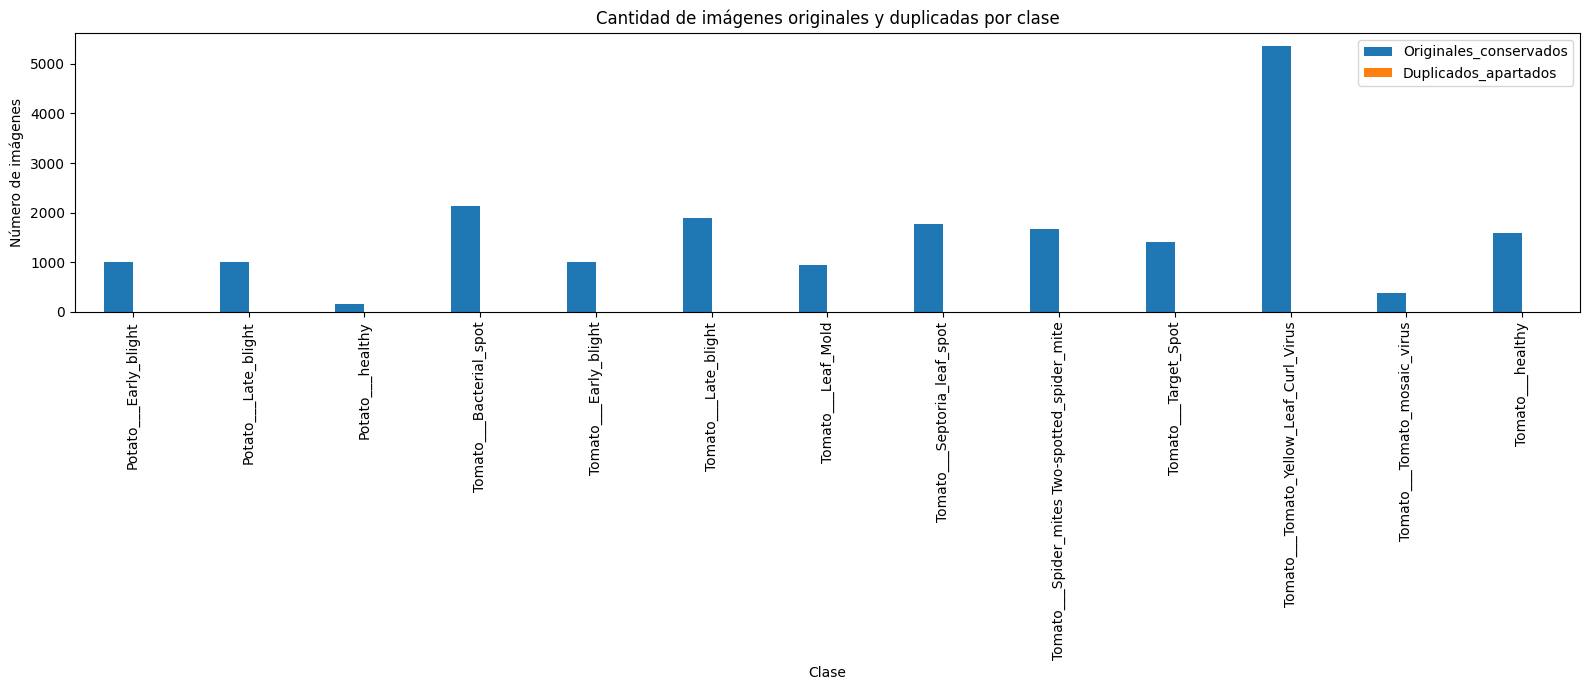

In [74]:
# ============================================================
# BLOQUE 11
# VISUALIZACIÓN ORIGINALES VS DUPLICADOS
# ============================================================

import matplotlib.pyplot as plt


df_grafico = (
    df_comparacion
    .set_index("Clase")
    [
        [
            "Originales_conservados",
            "Duplicados_apartados"
        ]
    ]
)


ax = df_grafico.plot(
    kind="bar",
    figsize=(16, 7)
)


ax.set_title(
    "Cantidad de imágenes originales y duplicadas por clase"
)

ax.set_xlabel(
    "Clase"
)

ax.set_ylabel(
    "Número de imágenes"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

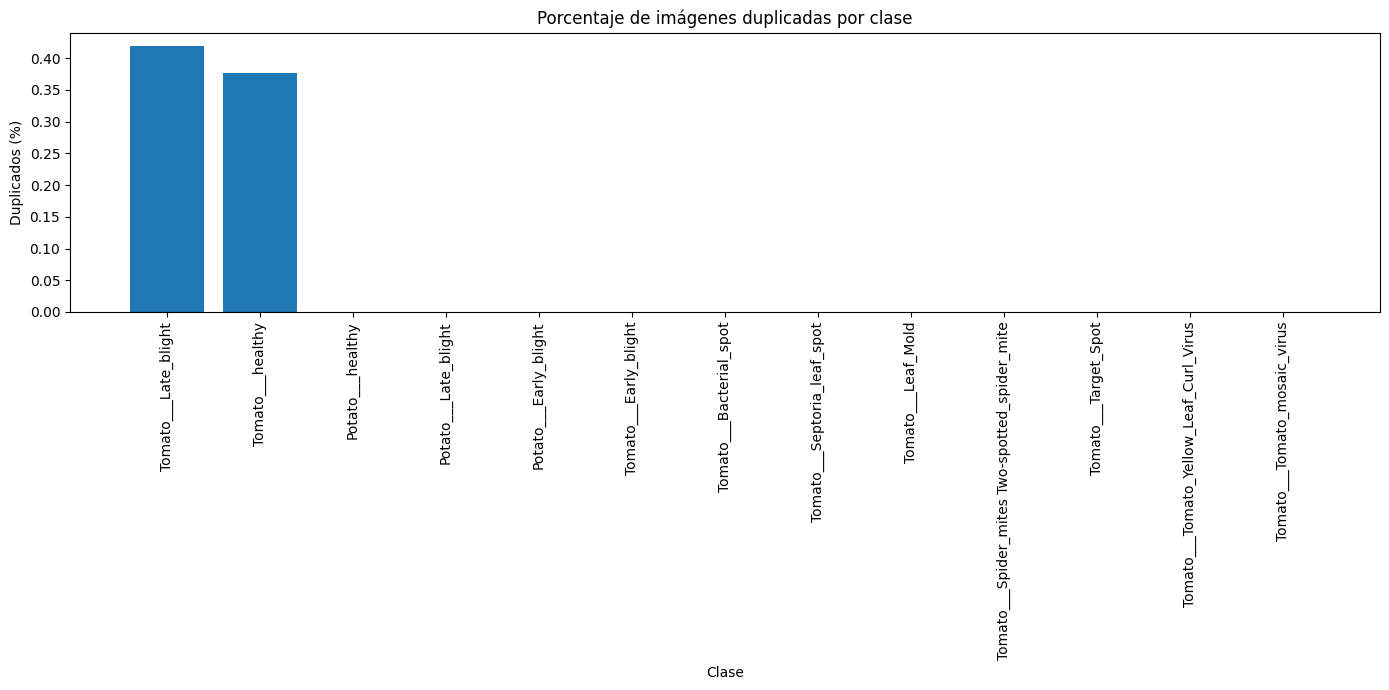

In [75]:
# ============================================================
# BLOQUE 12
# PORCENTAJE DE DUPLICADOS POR CLASE
# ============================================================

df_porcentaje = (
    df_comparacion
    .sort_values(
        "Duplicados_%",
        ascending=False
    )
)


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    df_porcentaje["Clase"],
    df_porcentaje["Duplicados_%"]
)


plt.title(
    "Porcentaje de imágenes duplicadas por clase"
)

plt.xlabel(
    "Clase"
)

plt.ylabel(
    "Duplicados (%)"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [76]:
# ============================================================
# BLOQUE 13
# EXPORTAR TABLA COMPARATIVA
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "comparacion_originales_vs_duplicados.csv"
)


df_comparacion.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Reporte guardado correctamente:"
)

print(RUTA_REPORTE)

✅ Reporte guardado correctamente:
/content/plantvillage/comparacion_originales_vs_duplicados.csv


# F2